In [79]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashyou09/indian-patient-disease-and-treatment-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\omjee\.cache\kagglehub\datasets\ashyou09\indian-patient-disease-and-treatment-dataset\versions\1


In [80]:
import os 

path = r"C:\Users\omjee\.cache\kagglehub\datasets\ashyou09"

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\omjee\.cache\kagglehub\datasets\ashyou09\indian-patient-disease-and-treatment-dataset\1.complete
C:\Users\omjee\.cache\kagglehub\datasets\ashyou09\indian-patient-disease-and-treatment-dataset\versions\1\indian_diseases_dataset.csv


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_csv(r"C:\Users\omjee\.cache\kagglehub\datasets\ashyou09\indian-patient-disease-and-treatment-dataset\versions\1\indian_diseases_dataset.csv")

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          20000 non-null  object 
 1   age                 20000 non-null  int64  
 2   age_group           20000 non-null  object 
 3   gender              20000 non-null  object 
 4   state               20000 non-null  object 
 5   city                20000 non-null  object 
 6   region              20000 non-null  object 
 7   urban_rural         20000 non-null  object 
 8   disease_name        20000 non-null  object 
 9   disease_category    20000 non-null  object 
 10  severity            20000 non-null  object 
 11  diagnosis_date      20000 non-null  object 
 12  year                20000 non-null  int64  
 13  month               20000 non-null  object 
 14  season              20000 non-null  object 
 15  symptoms            20000 non-null  object 
 16  como

In [84]:
df.isnull().sum()

patient_id                0
age                       0
age_group                 0
gender                    0
state                     0
city                      0
region                    0
urban_rural               0
disease_name              0
disease_category          0
severity                  0
diagnosis_date            0
year                      0
month                     0
season                    0
symptoms                  0
comorbidity            6599
smoking_status            0
alcohol_use            6627
bmi                       0
blood_group               0
income_level              0
insurance_status          0
treatment_type            0
hospital_type             0
days_hospitalized         0
treatment_cost_inr        0
outcome                   0
death_flag                0
cause_of_death        18178
recovery_days          6307
follow_up_required        0
dtype: int64

In [85]:
df.head()

,patient_id,age,age_group,gender,state,city,region,urban_rural,disease_name,disease_category,...,insurance_status,treatment_type,hospital_type,days_hospitalized,treatment_cost_inr,outcome,death_flag,cause_of_death,recovery_days,follow_up_required
0,IND-00000001,70,70-79,Female,Bihar,Patna,East,Semi-Urban,Diarrhea,Waterborne,...,Employer,Medication,Government,21,102.0,Recovering,0,NaN,42.0,Yes
1,IND-00000002,27,20-29,Other,Gujarat,Surat,West,Urban,Chikungunya,Vector-Borne,...,Uninsured,Medication,Government,0,1151.0,Recovered,0,NaN,18.0,Yes
2,IND-00000003,66,60-69,Other,Jharkhand,Bokaro,East,Rural,Hypertension,Non-Communicable,...,Private,Medication,Government,2,89.0,Chronic Management,0,NaN,NaN,Yes
3,IND-00000004,27,20-29,Female,Karnataka,Hubli,South,Rural,Tuberculosis,Infectious,...,Private,Surgery,Government,9,1269.0,Recovering,0,NaN,69.0,Yes
4,IND-00000005,40,40-49,Male,Karnataka,Belagavi,South,Rural,Chronic Kidney Disease,Non-Communicable,...,Ayushman Bharat,Palliative,Private,31,670576.0,Deceased,1,Complications from Chronic Kidney Disease,NaN,No


# filling null comorbidity

In [87]:
df["comorbidity"] = df["comorbidity"].fillna("No Comorbidity")

In [88]:
df["comorbidity"].value_counts()

comorbidity
No Comorbidity    6599
Kidney Disease    2314
Diabetes          2242
Obesity           2236
Multiple          2219
Heart Disease     2217
Hypertension      2173
Name: count, dtype: int64

# Alcohol users filling

In [90]:
df["alcohol_use"] = df["alcohol_use"].fillna("Not alcohol User")

In [91]:
df["alcohol_use"].value_counts()

alcohol_use
Occasional          6697
Not alcohol User    6627
Heavy               3343
Regular             3333
Name: count, dtype: int64

# cause of death

In [93]:
df["cause_of_death"].isnull().sum()

18178

In [94]:
df["cause_of_death"] = df["cause_of_death"].fillna("No Death Occur")

# filling recovery days

In [96]:
df["recovery_days"].value_counts()

recovery_days
26.0    398
22.0    397
28.0    393
30.0    385
27.0    376
       ... 
43.0     51
61.0     51
34.0     50
93.0     48
83.0     47
Name: count, Length: 98, dtype: int64

In [97]:
df['recovery_days']=df["recovery_days"].fillna(df["recovery_days"].mean())

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          20000 non-null  object 
 1   age                 20000 non-null  int64  
 2   age_group           20000 non-null  object 
 3   gender              20000 non-null  object 
 4   state               20000 non-null  object 
 5   city                20000 non-null  object 
 6   region              20000 non-null  object 
 7   urban_rural         20000 non-null  object 
 8   disease_name        20000 non-null  object 
 9   disease_category    20000 non-null  object 
 10  severity            20000 non-null  object 
 11  diagnosis_date      20000 non-null  object 
 12  year                20000 non-null  int64  
 13  month               20000 non-null  object 
 14  season              20000 non-null  object 
 15  symptoms            20000 non-null  object 
 16  como

In [99]:
df.duplicated().sum()

0

In [100]:
df.head()

,patient_id,age,age_group,gender,state,city,region,urban_rural,disease_name,disease_category,...,insurance_status,treatment_type,hospital_type,days_hospitalized,treatment_cost_inr,outcome,death_flag,cause_of_death,recovery_days,follow_up_required
0,IND-00000001,70,70-79,Female,Bihar,Patna,East,Semi-Urban,Diarrhea,Waterborne,...,Employer,Medication,Government,21,102.0,Recovering,0,No Death Occur,42.000000,Yes
1,IND-00000002,27,20-29,Other,Gujarat,Surat,West,Urban,Chikungunya,Vector-Borne,...,Uninsured,Medication,Government,0,1151.0,Recovered,0,No Death Occur,18.000000,Yes
2,IND-00000003,66,60-69,Other,Jharkhand,Bokaro,East,Rural,Hypertension,Non-Communicable,...,Private,Medication,Government,2,89.0,Chronic Management,0,No Death Occur,33.205141,Yes
3,IND-00000004,27,20-29,Female,Karnataka,Hubli,South,Rural,Tuberculosis,Infectious,...,Private,Surgery,Government,9,1269.0,Recovering,0,No Death Occur,69.000000,Yes
4,IND-00000005,40,40-49,Male,Karnataka,Belagavi,South,Rural,Chronic Kidney Disease,Non-Communicable,...,Ayushman Bharat,Palliative,Private,31,670576.0,Deceased,1,Complications from Chronic Kidney Disease,33.205141,No


In [101]:
#import sheryanalysis as sh

#sh.analyze(df)

In [131]:
cols = ['age','gender',
        'bmi','disease_category','severity','comorbidity','smoking_status',
        'alcohol_use','income_level','insurance_status','hospital_type',
        'treatment_type','days_hospitalized','treatment_cost_inr','death_flag']

In [133]:
final_df = df[cols]

In [135]:
final_df.head()

,age,gender,bmi,disease_category,severity,comorbidity,smoking_status,alcohol_use,income_level,insurance_status,hospital_type,treatment_type,days_hospitalized,treatment_cost_inr,death_flag
0,70,Female,20.1,Waterborne,Severe,No Comorbidity,Never,Not alcohol User,Middle,Employer,Government,Medication,21,102.0,0
1,27,Other,18.3,Vector-Borne,Mild,Kidney Disease,Never,Regular,High,Uninsured,Government,Medication,0,1151.0,0
2,66,Other,25.3,Non-Communicable,Mild,Heart Disease,Never,Not alcohol User,Below Poverty Line,Private,Government,Medication,2,89.0,0
3,27,Female,19.5,Infectious,Severe,No Comorbidity,Never,Occasional,Lower,Private,Government,Surgery,9,1269.0,0
4,40,Male,29.3,Non-Communicable,Critical,Kidney Disease,Former,Regular,Middle,Ayushman Bharat,Private,Palliative,31,670576.0,1


<Axes: xlabel='death_flag'>

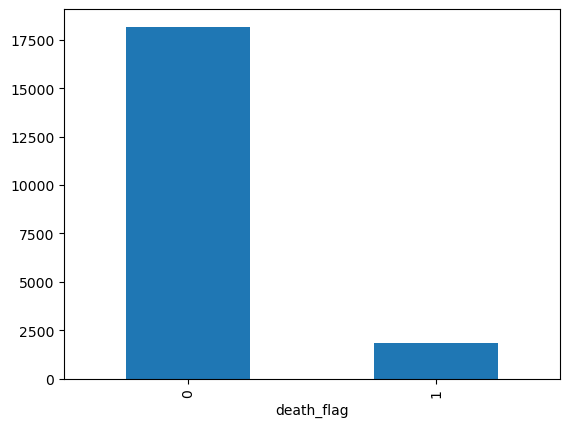

In [137]:
final_df["death_flag"].value_counts().plot(kind = "bar")

In [167]:
final_df.head()

,age,gender,bmi,disease_category,severity,comorbidity,smoking_status,alcohol_use,income_level,insurance_status,hospital_type,treatment_type,days_hospitalized,treatment_cost_inr,death_flag
0,70,Female,20.1,Waterborne,Severe,No Comorbidity,Never,Not alcohol User,Middle,Employer,Government,Medication,21,102.0,0
1,27,Other,18.3,Vector-Borne,Mild,Kidney Disease,Never,Regular,High,Uninsured,Government,Medication,0,1151.0,0
2,66,Other,25.3,Non-Communicable,Mild,Heart Disease,Never,Not alcohol User,Below Poverty Line,Private,Government,Medication,2,89.0,0
3,27,Female,19.5,Infectious,Severe,No Comorbidity,Never,Occasional,Lower,Private,Government,Surgery,9,1269.0,0
4,40,Male,29.3,Non-Communicable,Critical,Kidney Disease,Former,Regular,Middle,Ayushman Bharat,Private,Palliative,31,670576.0,1


In [169]:
df_encoded = pd.get_dummies(final_df,columns=["gender",
                                              "disease_category","severity",
                                              "comorbidity","smoking_status",
                                              "alcohol_use","income_level",
                                              "insurance_status","hospital_type",
                                              "treatment_type",],drop_first= True)
                            
                                              

In [173]:
df_encoded.astype(int)

,age,bmi,days_hospitalized,treatment_cost_inr,death_flag,gender_Male,gender_Other,disease_category_Infectious,disease_category_Mental Health,disease_category_Non-Communicable,...,hospital_type_Community Health Center,hospital_type_Government,hospital_type_Primary Health Center,hospital_type_Private,treatment_type_ICU + Ventilator,treatment_type_Medication,treatment_type_Observation,treatment_type_Palliative,treatment_type_Surgery,treatment_type_Therapy
0,70,20,21,102,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,27,18,0,1151,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,66,25,2,89,0,0,1,0,0,1,...,0,1,0,0,0,1,0,0,0,0
3,27,19,9,1269,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,40,29,31,670576,1,1,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,73,19,6,44863,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
19996,76,22,1,1590,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
19997,21,19,8,11361,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
19998,48,31,0,3307,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [237]:
df_encoded.to_csv("df_encoded.csv", index=False)

In [177]:
X = df_encoded.drop('treatment_cost_inr',axis = 1)
y = df_encoded['treatment_cost_inr']

# splitting data for train test

In [180]:
from sklearn.model_selection import train_test_split

In [182]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 20,random_state= 42)

# random forest regression

In [186]:
from sklearn.ensemble import RandomForestRegressor


In [188]:
forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

forest.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [190]:
y_pred = forest.predict(X_test)

In [196]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("Random Forest R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Random Forest R2: 0.8397377367553499
MAE: 38010.188749999994
MSE: 5960747608.632194


In [246]:
import joblib

# Train final model on full data
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

# Save model
joblib.dump(model, "treatment_cost_model.pkl")

# Save columns (VERY IMPORTANT)
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model and columns saved successfully!")

Model and columns saved successfully!
